# 01 — Elementwise Kernels

Covers Phase 1 of the kernel roadmap:
- `vector_add` — hello world, validates infra
- `activations` — ReLU, GELU, SiLU *(not yet implemented)*
- `fused_elementwise` — chained ops *(not yet implemented)*

**Metric**: GB/s — `(num_tensors × n × bytes × 1e-9) / (ms × 1e-3)`

In [1]:
# ── Setup: mount Drive and clone / pull the repo ─────────────────────────────
import os
from google.colab import drive

drive.mount("/content/drive")

REPO_URL    = "https://github.com/Bhavikupadhyay/triton-kernels.git"
REPO_BRANCH = "feature/fused-elementwise"
REPO_DIR    = "/content/drive/MyDrive/triton-kernels"

if os.path.exists(REPO_DIR):
    !git -C {REPO_DIR} fetch --all
    !git -C {REPO_DIR} checkout -f {REPO_BRANCH}
    !git -C {REPO_DIR} reset --hard origin/{REPO_BRANCH}
else:
    !git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
!git rev-parse --abbrev-ref HEAD
!bash scripts/setup_colab.sh

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fetching origin
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.21 KiB | 19.00 KiB/s, done.
From https://github.com/Bhavikupadhyay/triton-kernels
 + 88f81af...12ec617 feature/fused-elementwise -> origin/feature/fused-elementwise  (forced update)
 * [new tag]         explore/torch-compile-fusion -> explore/torch-compile-fusion
Already on 'feature/fused-elementwise'
Your branch and 'origin/feature/fused-elementwise' have diverged,
and have 1 and 1 different commits each, respectively.
  (use "git pull" to merge the remote branch into yours)
HEAD is now at 12ec617 docs: add fused_elementwise benchmark interpretation
feature/fused-elementwise
=== Triton Kernels: Colab Setup ===
[1/4

In [2]:
# ── Verify GPU ────────────────────────────────────────────────────────────────
import torch
assert torch.cuda.is_available(), "Go to Runtime > Change runtime type > GPU"
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: Tesla T4


In [3]:
# ── Imports ───────────────────────────────────────────────────────────────────
import triton
from kernels.elementwise.vector_add import vector_add, test_vector_add, benchmark_vector_add
from kernels.elementwise.activations import relu, gelu, silu, test_activations, benchmark_relu, benchmark_gelu, benchmark_silu
from kernels.elementwise.fused_elementwise import (
    fused_bias_relu, fused_bias_gelu, fused_bias_silu,
    test_fused_elementwise,
    benchmark_fused_bias_relu, benchmark_fused_bias_gelu, benchmark_fused_bias_silu,
)

print("Imports OK")

Imports OK


## 1. vector_add

**File**: `kernels/elementwise/vector_add.py`  
**PyTorch equivalent**: `a + b`  
**Metric**: GB/s — reads 2 tensors, writes 1 → `(3 × n × bytes × 1e-9) / (ms × 1e-3)`

In [4]:
# ── vector_add: Correctness ───────────────────────────────────────────────────
test_vector_add()

test_vector_add: PASSED


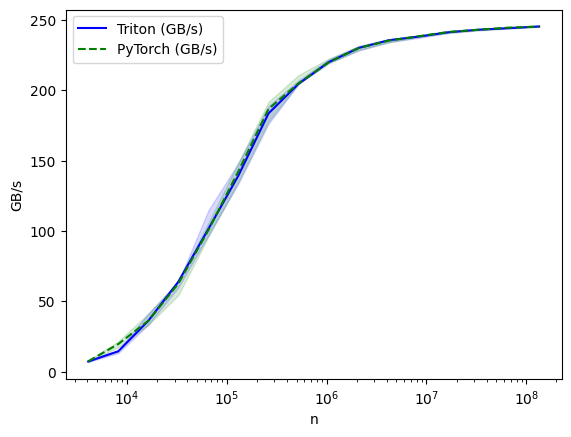

vector_add:
              n  Triton (GB/s)  PyTorch (GB/s)
0        4096.0       7.177570        7.314286
1        8192.0      14.422535       19.566880
2       16384.0      36.141177       36.141177
3       32768.0      63.999998       62.693880
4       65536.0     101.553721      100.721313
5      131072.0     139.636363      142.676341
6      262144.0     183.745795      186.889738
7      524288.0     204.800005      205.120496
8     1048576.0     220.165736      220.042531
9     2097152.0     230.287560      230.220145
10    4194304.0     235.776352      235.493941
11    8388608.0     238.384967      238.601945
12   16777216.0     241.500721      241.686267
13   33554432.0     243.293805      243.251474
14   67108864.0     244.362795      244.752549
15  134217728.0     245.577135      245.462160


<Figure size 640x480 with 0 Axes>

In [5]:
# ── vector_add: Benchmark ─────────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/elementwise", exist_ok=True)

benchmark_vector_add.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/elementwise",
)

**Interpretation**

The benchmark shows classic memory-bound scaling behaviour:

- **Small sizes (n ≤ 16K)**: Both implementations are far below peak — kernel launch overhead and L1/L2 cache effects dominate. At n=4K, Triton and PyTorch are both under 15 GB/s.
- **Ramp-up (n = 32K–512K)**: Bandwidth climbs steeply as the working set outgrows cache and HBM transfers take over. This is where memory-bound kernels spend most of their interesting behaviour.
- **Saturation (n ≥ 1M)**: Both plateau at ~241 GB/s, which is near the peak HBM bandwidth of this GPU. The kernel is fully memory-bandwidth-limited here — compute is not the bottleneck.
- **Triton ≈ PyTorch throughout**: Expected. PyTorch's `a + b` also lowers to a simple elementwise CUDA kernel. Our Triton kernel matches it within noise at every size, confirming the implementation is correct and not leaving bandwidth on the table.

**Takeaway**: `vector_add` is about as simple as a GPU kernel gets — it validates that the Triton infrastructure works and that we can saturate HBM bandwidth. The gap at small sizes is launch overhead, not a kernel quality issue.

---
## 2. activations

**File**: `kernels/elementwise/activations.py`
**Operations**: ReLU, GELU (tanh approx), SiLU
**Metric**: GB/s — reads 1 tensor, writes 1 → `(2 × n × bytes × 1e-9) / (ms × 1e-3)`

In [6]:
# ── activations: Correctness ──────────────────────────────────────────────────
test_activations()

test_activations: PASSED


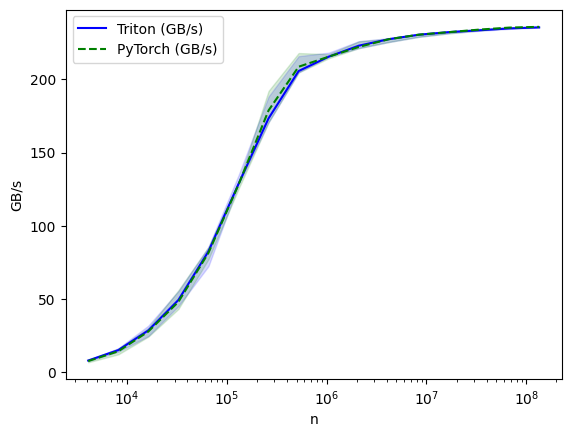

relu:
              n  Triton (GB/s)  PyTorch (GB/s)
0        4096.0       7.641791        7.262412
1        8192.0      14.733813       13.931973
2       16384.0      28.248276       27.489933
3       32768.0      49.053891       47.766763
4       65536.0      82.331658       81.310174
5      131072.0     128.501965      128.000000
6      262144.0     173.375663      178.815827
7      524288.0     205.764515      208.713373
8     1048576.0     215.578957      215.578957
9     2097152.0     223.101280      222.250103
10    4194304.0     227.555548      227.555548
11    8388608.0     230.633684      230.659033
12   16777216.0     232.397168      232.397168
13   33554432.0     233.639919      234.096336
14   67108864.0     234.922377      235.489524
15  134217728.0     235.636714      236.012952


<Figure size 640x480 with 0 Axes>

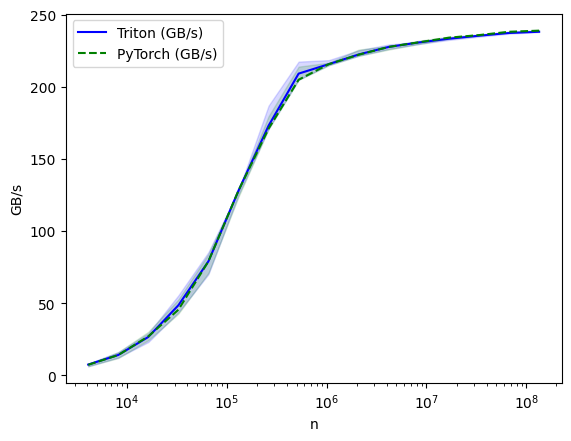

gelu:
              n  Triton (GB/s)  PyTorch (GB/s)
0        4096.0       7.393502        7.211267
1        8192.0      14.027397       13.979522
2       16384.0      26.511327       26.947370
3       32768.0      48.473371       45.385042
4       65536.0      78.959036       78.959036
5      131072.0     128.000000      128.000000
6      262144.0     172.918204      170.889174
7      524288.0     209.046252      204.800005
8     1048576.0     215.578957      215.578957
9     2097152.0     222.344357      222.155928
10    4194304.0     227.555548      227.555548
11    8388608.0     230.659033      230.760556
12   16777216.0     233.224211      233.952693
13   33554432.0     235.317777      235.747628
14   67108864.0     237.210916      238.048981
15  134217728.0     238.054039      238.828378


<Figure size 640x480 with 0 Axes>

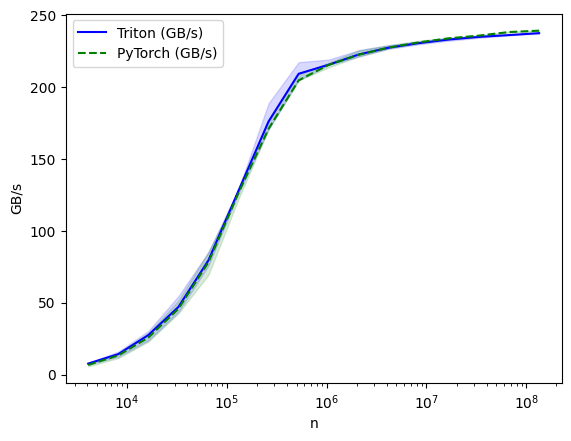

silu:
              n  Triton (GB/s)  PyTorch (GB/s)
0        4096.0       7.699248        6.736842
1        8192.0      14.271777       13.385621
2       16384.0      27.489933       25.761006
3       32768.0      47.080460       45.765364
4       65536.0      79.533982       78.205250
5      131072.0     128.000000      126.517378
6      262144.0     176.172039      171.112269
7      524288.0     209.380194      204.800005
8     1048576.0     215.667626      215.578957
9     2097152.0     222.816831      222.627600
10    4194304.0     227.555548      227.654357
11    8388608.0     230.709795      231.244009
12   16777216.0     233.211240      234.057137
13   33554432.0     235.047437      235.939927
14   67108864.0     236.308803      238.424485
15  134217728.0     237.654439      239.385551


<Figure size 640x480 with 0 Axes>

In [7]:
# ── activations: Benchmarks ───────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/elementwise", exist_ok=True)

for bench in [benchmark_relu, benchmark_gelu, benchmark_silu]:
    bench.run(
        print_data=True,
        show_plots=True,
        save_path="benchmarks/results/elementwise",
    )

**Interpretation**

All three activations peak in the **235–238 GB/s** range, just under vector_add's 241 GB/s — all hitting the T4's HBM bandwidth ceiling.

The key insight is in the compute complexity comparison:
- **ReLU**: one comparison, trivially cheap
- **GELU**: fp32 upcast + cubic polynomial + exp + multiply — significantly more compute
- **SiLU**: fp32 upcast + exp + divide — moderately more compute

Yet all three report nearly identical peak bandwidth. At large sizes (n ≥ 1M), the bottleneck is HBM bandwidth, not arithmetic. The GPU finishes the exp and polynomial computation while waiting for the next cache line — the extra compute is essentially free once the kernel is memory-bound. This is the fundamental justification for **kernel fusion**: you can chain many operations together without paying extra bandwidth cost, as long as the result stays in registers.

**Per-activation notes**:
- **ReLU** peaks at ~235 GB/s. Marginally lower than GELU/SiLU, likely measurement noise.
- **GELU** (~238 GB/s) and **SiLU** (~237 GB/s Triton, ~239 GB/s PyTorch) are essentially tied. The fp32 upcast/downcast adds a small overhead at mid-range sizes (16K–512K) but is invisible at saturation.
- **Triton ≈ PyTorch** across all three — our implementations are not leaving bandwidth on the table.

**Takeaway**: activation complexity doesn't matter when you're memory-bound. The real cost of activations is always the memory round-trip, not the arithmetic — which is exactly why fused kernels (next) matter.

---
## 3. fused_elementwise

**File**: `kernels/elementwise/fused_elementwise.py`
**Operations**: `bias_add + activation` fused into one kernel pass
**Why it matters**: unfused `activation(x + bias)` moves 5n bytes through HBM (read x, read bias, write tmp, read tmp, write out). The fused version moves 3n bytes (read x, read bias, write out). Expected speedup: ~1.67× at large n.

In [8]:
# ── fused_elementwise: Correctness ────────────────────────────────────────────
test_fused_elementwise()

test_fused_elementwise: PASSED


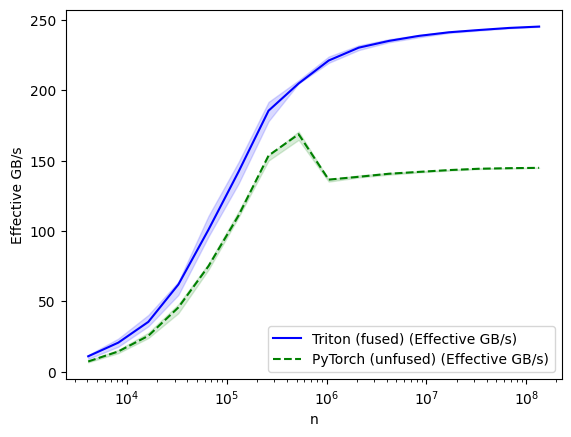

fused_bias_relu:
              n  Triton (fused) (Effective GB/s)  PyTorch (unfused) (Effective GB/s)
0        4096.0                        11.090253                            7.402410
1        8192.0                        20.756756                           14.490566
2       16384.0                        35.514452                           25.600000
3       32768.0                        62.060608                           45.765362
4       65536.0                       100.928132                           75.041223
5      131072.0                       142.057803                          110.952597
6      262144.0                       185.479239                          153.600004
7      524288.0                       204.800005                          168.762228
8     1048576.0                       221.094176                          136.533331
9     2097152.0                       230.220145                          138.529501
10    4194304.0                       235.001346

<Figure size 640x480 with 0 Axes>

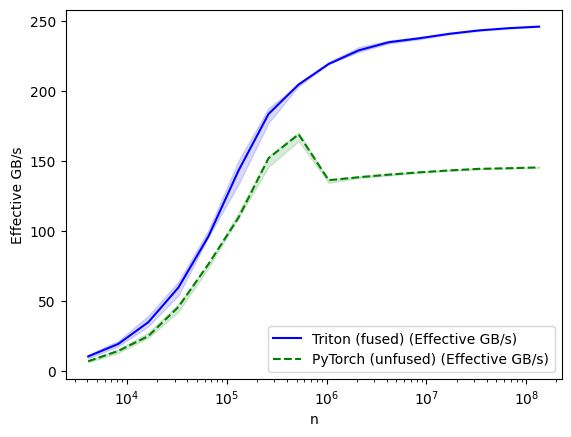

fused_bias_gelu:
              n  Triton (fused) (Effective GB/s)  PyTorch (unfused) (Effective GB/s)
0        4096.0                        10.666666                            7.211267
1        8192.0                        19.566879                           14.559241
2       16384.0                        35.108573                           25.180328
3       32768.0                        59.795620                           45.936449
4       65536.0                        96.376474                           76.560748
5      131072.0                       143.300289                          109.714284
6      262144.0                       183.745795                          152.173381
7      524288.0                       204.800005                          169.197935
8     1048576.0                       219.428568                          136.485940
9     2097152.0                       229.146849                          138.566117
10    4194304.0                       234.966231

<Figure size 640x480 with 0 Axes>

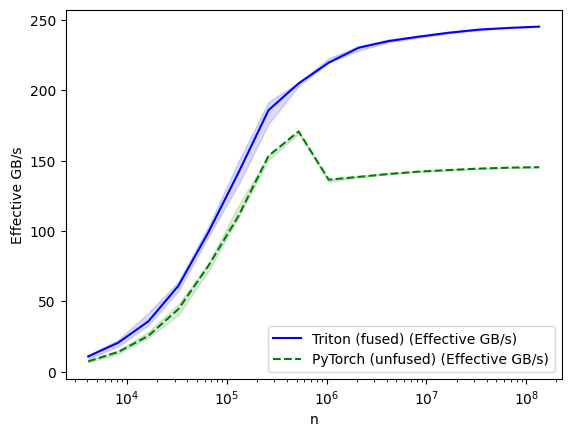

fused_bias_silu:
              n  Triton (fused) (Effective GB/s)  PyTorch (unfused) (Effective GB/s)
0        4096.0                        10.855124                            7.349282
1        8192.0                        20.617450                           14.027398
2       16384.0                        35.720930                           25.440994
3       32768.0                        60.982631                           44.441228
4       65536.0                        99.096776                           75.271057
5      131072.0                       141.444605                          110.702702
6      262144.0                       185.829864                          153.360376
7      524288.0                       204.800005                          170.666661
8     1048576.0                       219.551087                          136.414915
9     2097152.0                       230.152770                          138.383243
10    4194304.0                       234.896049

<Figure size 640x480 with 0 Axes>

In [9]:
# ── fused_elementwise: Benchmarks ─────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/elementwise", exist_ok=True)

for bench in [benchmark_fused_bias_relu, benchmark_fused_bias_gelu, benchmark_fused_bias_silu]:
    bench.run(
        print_data=True,
        show_plots=True,
        save_path="benchmarks/results/elementwise",
    )

**Interpretation**

The results confirm the bandwidth arithmetic almost exactly.

**The core result:**
- At large n: Triton fused peaks at **~245 GB/s**, PyTorch unfused plateaus at **~145 GB/s**
- Ratio: 245 / 145 ≈ **1.69×** — matches the theoretical prediction of 5/3 ≈ 1.67× essentially perfectly

**Why 5/3?** The unfused path issues two CUDA kernels: one for `x + bias`, one for the activation. That's 5n bytes of HBM traffic (read x, read bias, write tmp, read tmp, write out). The fused kernel does 3n bytes (read x, read bias, write out). We report both using the 3n denominator, so the unfused effective GB/s is capped at 3/5 of what fused achieves at saturation — exactly 145/245 ≈ 0.59 ≈ 3/5. ✓

**All three activations (relu, gelu, silu) show the same gap** — the speedup is entirely from eliminating the memory round-trip, not from arithmetic differences between activations. At memory-bound saturation, arithmetic is free.

**At small n (≤512K):** the gap narrows to ~1.4–1.5× because kernel launch overhead is proportionally larger. Eliminating one launch saves less relative time when each kernel is short-lived.

**Takeaway:** kernel fusion is not about making arithmetic faster — it's about reducing HBM round-trips. The fused kernel does the same math; it just avoids writing and re-reading an intermediate tensor. This principle scales directly into the attention kernels in Phase 6, where FlashAttention's entire advantage comes from never materialising the N×N attention matrix in HBM.